# DGD-TabPA: Prototype Demonstration

**Diffusion-Guided Dataset Distillation for Tabular Data with Privacy-Aware Evaluation**

This notebook demonstrates the end-to-end DGD-TabPA pipeline:

1. **Module 1**: Heterogeneous Data Ingestion & Preprocessing
2. **Module 2**: Transformer-based Denoising Network (training)
3. **Module 3**: Diffusion-Guided Distillation Loop
4. **Module 4**: DP-SGD Privacy Guardrails
5. **Module 5**: Multi-Dimensional Evaluation (DCR, TSTR, Wasserstein)

---

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

# Add project root to path
PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import TabularPreprocessor
from src.models.transformer import TabularTransformerDenoiser
from src.models.diffusion import GaussianDiffusion
from src.distillation.loop import DistillationLoop
from src.privacy.dp_sgd import DPSGDWrapper
from src.evaluation.evaluate import Evaluator

# Configuration
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

Device: cpu
PyTorch: 2.11.0+cpu


## Module 1: Heterogeneous Data Ingestion & Preprocessing

We load the **Adult Income** dataset and apply:
- Gaussian Quantile Transformation for numerical features
- One-Hot Encoding for categorical features

In [2]:
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
DATASET = 'adult'
TARGET_COL = 'income'

data_path = DATA_DIR / f'{DATASET}.csv'
if not data_path.exists():
    print('Dataset not found. Downloading...')
    %run ../scripts/download_data.py --dataset adult

preprocessor = TabularPreprocessor(random_state=SEED)
X_train, X_test, y_train, y_test = preprocessor.load_dataset(
    name=DATASET,
    filepath=str(data_path),
    target_col=TARGET_COL,
    test_size=0.2,
)

X_train_t, y_train_t = preprocessor.fit_transform(X_train, y_train)
X_test_t, y_test_t = preprocessor.transform(X_test, y_test)

info = preprocessor.info
print(f'\nDataset: {info.name}')
print(f'  Numerical features ({info.num_dim}): {info.num_features}')
print(f'  Categorical features ({len(info.cat_features)}): {info.cat_features}')
print(f'  Total input dimension (after encoding): {info.total_dim}')
print(f'  Classes: {info.num_classes}')
print(f'  Train samples: {len(X_train_t)}')
print(f'  Test samples: {len(X_test_t)}')
print(f'\nTransformed tensor shape: {X_train_t.shape}')
print(f'Mean: {X_train_t.mean():.4f}, Std: {X_train_t.std():.4f}')


Dataset: adult
  Numerical features (6): ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
  Categorical features (8): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country']
  Total input dimension (after encoding): 108
  Classes: 2
  Train samples: 39073
  Test samples: 9769

Transformed tensor shape: torch.Size([39073, 108])
Mean: -0.0135, Std: 0.7679


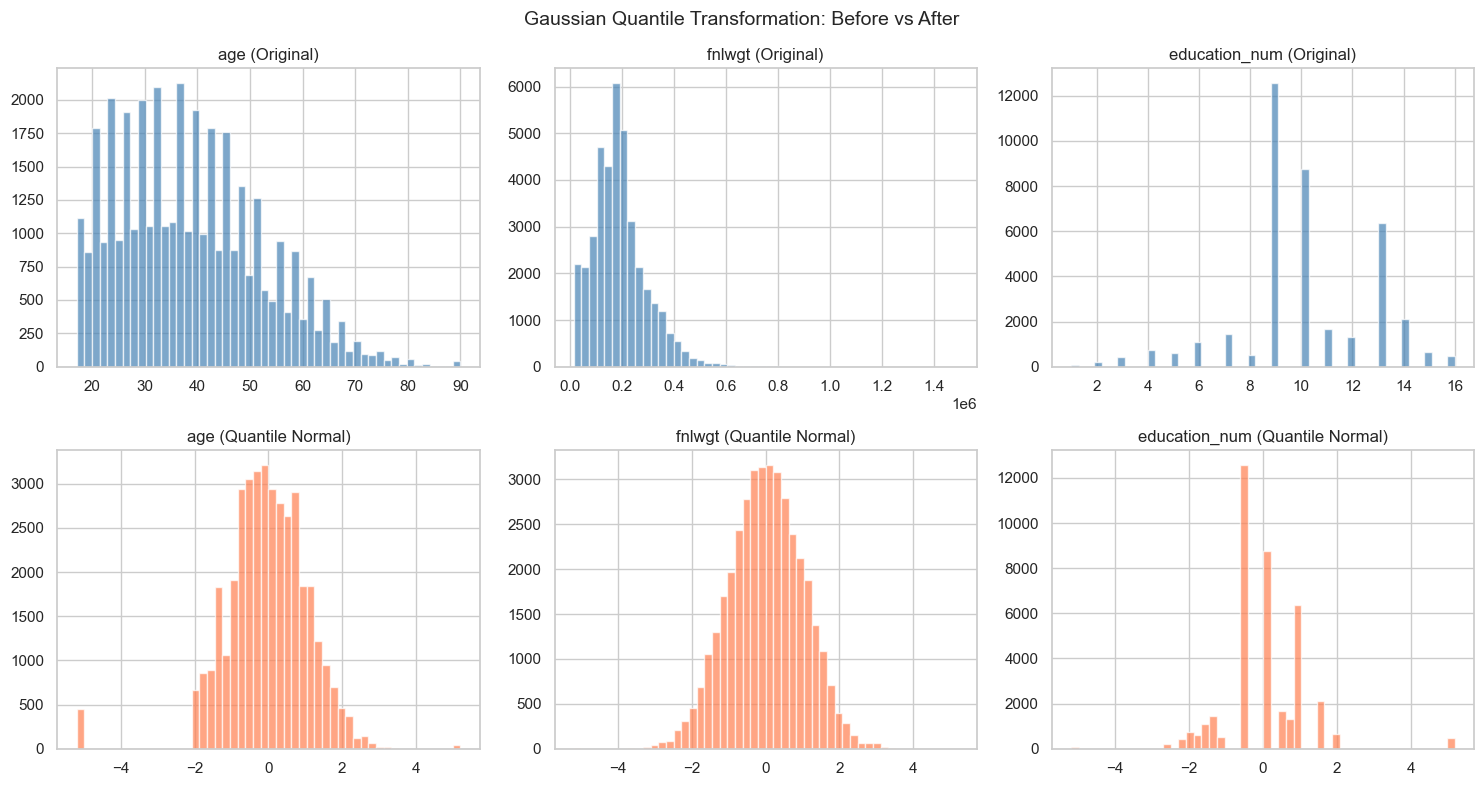

In [3]:
# Visualize the effect of Gaussian Quantile Transformation
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Gaussian Quantile Transformation: Before vs After', fontsize=14)

num_cols_to_show = min(3, len(info.num_features))
for i in range(num_cols_to_show):
    col = info.num_features[i]
    # Before (original)
    axes[0, i].hist(X_train[col].values, bins=50, alpha=0.7, color='steelblue')
    axes[0, i].set_title(f'{col} (Original)')
    # After (transformed)
    axes[1, i].hist(X_train_t[:, i].numpy(), bins=50, alpha=0.7, color='coral')
    axes[1, i].set_title(f'{col} (Quantile Normal)')

plt.tight_layout()
plt.show()

## Module 2 & 3: Diffusion Model Training

We build the Transformer-based denoising network with:
- **Encoder**: processes conditioned (unmasked) features
- **Decoder**: Conditioning Attention Mechanism (Q=masked, K/V=condition)
- **Dynamic Masking**: unified generation & imputation

The DDPM forward process adds Gaussian noise; the reverse process denoises.

In [4]:
# Build the model
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 3
NUM_TIMESTEPS = 1000

denoiser = TabularTransformerDenoiser(
    total_dim=info.total_dim,
    num_classes=info.num_classes,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_encoder_layers=N_LAYERS,
    n_decoder_layers=N_LAYERS,
    d_ff=D_MODEL * 4,
    dropout=0.1,
)

diffusion = GaussianDiffusion(
    denoiser=denoiser,
    num_timesteps=NUM_TIMESTEPS,
    beta_start=0.0001,
    beta_end=0.02,
    beta_schedule='linear',
    loss_type='mse',
).to(DEVICE)

total_params = sum(p.numel() for p in diffusion.parameters())
print(f'Total parameters: {total_params:,}')
print(f'Timesteps: {NUM_TIMESTEPS}')
print(f'Architecture: Transformer Encoder-Decoder (d={D_MODEL}, heads={N_HEADS}, layers={N_LAYERS})')

Total parameters: 1,576,300
Timesteps: 1000
Architecture: Transformer Encoder-Decoder (d=128, heads=4, layers=3)


C:\Users\SuranjaLiyanage\Documents\Personal\MSc\MSc Project\DGD-TabPA\src\models\transformer.py:147: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=n_encoder_layers)


In [5]:
# Training loop
EPOCHS = 10  # Keep low for live demo (~5 min on CPU); use 100+ for best results
BATCH_SIZE = 256
LR = 1e-4

train_ds = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

optimizer = torch.optim.AdamW(diffusion.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

loss_history = []

print(f'Training for {EPOCHS} epochs...')
for epoch in tqdm(range(1, EPOCHS + 1), desc='Training'):
    diffusion.train()
    epoch_loss = 0.0
    n_batches = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        t = torch.randint(0, NUM_TIMESTEPS, (X_batch.size(0),), device=DEVICE)
        loss = diffusion.compute_loss(X_batch, t, y_batch, mask_ratio=1.0)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(diffusion.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    scheduler.step()
    avg_loss = epoch_loss / max(n_batches, 1)
    loss_history.append(avg_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'  Epoch {epoch}/{EPOCHS} | Loss: {avg_loss:.6f}')

print(f'\nTraining complete. Final loss: {loss_history[-1]:.6f}')

Training for 10 epochs...


ImportError: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html

In [ ]:
# Plot training loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(loss_history, color='steelblue', linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('DGD-TabPA Diffusion Model Training Loss')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Sample Generation & Quality Check

Generate synthetic samples and compare distributions with real data.

In [ ]:
# Generate synthetic samples
N_GEN = 500
SAMPLING_STEPS = 20

diffusion.eval()

# Balanced label generation
gen_labels = torch.cat([
    torch.full((N_GEN // info.num_classes,), c, dtype=torch.long)
    for c in range(info.num_classes)
])[:N_GEN].to(DEVICE)

print(f'Generating {N_GEN} synthetic samples with {SAMPLING_STEPS} sampling steps...')
with torch.no_grad():
    generated = diffusion.sample(
        labels=gen_labels,
        shape=(N_GEN, info.total_dim),
        device=DEVICE,
        sampling_steps=SAMPLING_STEPS,
    )

print(f'Generated shape: {generated.shape}')
print(f'Generated mean: {generated.mean():.4f}, std: {generated.std():.4f}')
print(f'Real mean: {X_train_t.mean():.4f}, std: {X_train_t.std():.4f}')

In [ ]:
# Compare distributions: Real vs Generated (numerical features in latent space)
n_show = min(6, info.num_dim)
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 7))
fig.suptitle('Real vs Generated Feature Distributions (Latent Space)', fontsize=14)

real_np = X_train_t[:N_GEN].numpy()
gen_np = generated.cpu().numpy()

for i in range(n_show):
    col_name = info.num_features[i] if i < len(info.num_features) else f'dim_{i}'
    axes[0, i].hist(real_np[:, i], bins=40, alpha=0.7, color='steelblue', density=True)
    axes[0, i].set_title(f'{col_name} (Real)')
    axes[1, i].hist(gen_np[:, i], bins=40, alpha=0.7, color='coral', density=True)
    axes[1, i].set_title(f'{col_name} (Generated)')

plt.tight_layout()
plt.show()

## Module 3: Diffusion-Guided Distillation

Condense the training set into a much smaller set of synthetic samples
using bi-level optimization with distribution matching (MMD loss).

In [ ]:
# Distillation
NUM_SYNTHETIC = 500
DISTILL_EPOCHS = 100  # Reduced for demo

distiller = DistillationLoop(
    diffusion_model=diffusion,
    total_dim=info.total_dim,
    num_classes=info.num_classes,
    num_synthetic=NUM_SYNTHETIC,
    distill_lr=0.01,
    distill_epochs=DISTILL_EPOCHS,
    inner_steps=10,
    device=DEVICE,
)

syn_data, syn_labels, distill_loss = distiller.distill(X_train_t, y_train_t)

compression_ratio = len(X_train_t) / NUM_SYNTHETIC
print(f'\nDistillation complete!')
print(f'  {len(X_train_t)} real samples -> {NUM_SYNTHETIC} distilled samples')
print(f'  Compression ratio: {compression_ratio:.1f}x')

In [ ]:
# Plot distillation loss
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(distill_loss, color='darkgreen', linewidth=1.5)
ax.set_xlabel('Distillation Epoch')
ax.set_ylabel('MMD Loss')
ax.set_title('Diffusion-Guided Distillation: MMD Convergence')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Module 4: Privacy Guardrails (DP-SGD)

Demonstrate the privacy-utility trade-off by showing how different
epsilon values affect the quality of synthetic data.

In [ ]:
# Demonstrate DP-SGD configuration
dp_wrapper = DPSGDWrapper(
    enabled=True,
    target_epsilon=8.0,
    target_delta=1e-5,
    max_grad_norm=1.0,
)

print('DP-SGD Privacy Configuration:')
print(f'  Epsilon (privacy budget): {dp_wrapper.target_epsilon}')
print(f'  Delta: {dp_wrapper.target_delta}')
print(f'  Max gradient norm: {dp_wrapper.max_grad_norm}')
print()
print('Privacy-Utility Trade-off Guide:')
print('  epsilon=1.0  -> Strong privacy, lower utility')
print('  epsilon=8.0  -> Moderate privacy, good utility')
print('  epsilon=inf  -> No privacy, best utility')
print()
print('Note: DP-SGD wraps the optimizer with Opacus to clip per-sample')
print('gradients and inject calibrated Gaussian noise during training.')
print('This provides mathematical guarantees against membership inference attacks.')

## Module 5: Multi-Dimensional Evaluation

Evaluate the distilled data across three dimensions:
- **Resemblance**: Wasserstein distance, KS-test, PCD
- **Utility (TSTR)**: Train on Synthetic, Test on Real — F1-score
- **Privacy**: Distance to Closest Record (DCR)

In [ ]:
# Inverse transform distilled data back to original space
syn_df = preprocessor.inverse_transform(syn_data)
syn_label_names = preprocessor.inverse_transform_labels(syn_labels)
syn_df[TARGET_COL] = syn_label_names

# Reconstruct real DataFrames with labels
real_train_df = X_train.copy()
real_train_df[TARGET_COL] = y_train

real_test_df = X_test.copy()
real_test_df[TARGET_COL] = y_test

print(f'Distilled data shape: {syn_df.shape}')
print(f'\nSample distilled records:')
syn_df.head()

In [ ]:
# Run full evaluation
evaluator = Evaluator(random_state=SEED)
results = evaluator.evaluate_all(
    real_train=real_train_df,
    real_test=real_test_df,
    synthetic=syn_df,
    target_col=TARGET_COL,
)

evaluator.print_report()

In [ ]:
# Visualize evaluation results
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Utility comparison (TSTR vs TRTR)
utility = results.get('utility', {})
model_names = []
trtr_scores = []
tstr_scores = []
for name, metrics in utility.items():
    if isinstance(metrics, dict) and 'tstr_f1' in metrics:
        model_names.append(name.upper())
        trtr_scores.append(metrics['trtr_f1'])
        tstr_scores.append(metrics['tstr_f1'])

if model_names:
    x_pos = np.arange(len(model_names))
    width = 0.35
    axes[0].bar(x_pos - width/2, trtr_scores, width, label='TRTR (Baseline)', color='steelblue')
    axes[0].bar(x_pos + width/2, tstr_scores, width, label='TSTR (Synthetic)', color='coral')
    axes[0].set_xlabel('Downstream Model')
    axes[0].set_ylabel('F1 Score')
    axes[0].set_title('ML Utility: TRTR vs TSTR')
    axes[0].set_xticks(x_pos)
    axes[0].set_xticklabels(model_names)
    axes[0].legend()
    axes[0].set_ylim(0, 1.05)

# 2. Wasserstein distances
wasserstein = results.get('resemblance', {}).get('wasserstein_per_column', {})
if wasserstein:
    cols = list(wasserstein.keys())[:8]
    vals = [wasserstein[c] for c in cols]
    axes[1].barh(cols, vals, color='teal', alpha=0.8)
    axes[1].set_xlabel('Wasserstein Distance')
    axes[1].set_title('Statistical Resemblance')
    axes[1].invert_yaxis()

# 3. Privacy metrics
privacy = results.get('privacy', {})
if 'dcr_median' in privacy:
    metrics_names = ['DCR Median', 'DCR Mean', 'DCR 5th %ile', 'DCR Min']
    metrics_vals = [
        privacy['dcr_median'],
        privacy['dcr_mean'],
        privacy['dcr_5th_percentile'],
        privacy['dcr_min'],
    ]
    colors = ['forestgreen' if v > 0.1 else 'orange' if v > 0.01 else 'red' for v in metrics_vals]
    axes[2].bar(metrics_names, metrics_vals, color=colors, alpha=0.8)
    axes[2].set_ylabel('Distance')
    axes[2].set_title(f'Privacy (DCR) — Rating: {privacy.get("privacy_rating", "N/A")}')
    axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('DGD-TabPA Multi-Dimensional Evaluation Dashboard', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Summary

This prototype demonstrates the complete DGD-TabPA pipeline:

| Module | Component | Status |
|--------|-----------|--------|
| Module 1 | Heterogeneous Data Preprocessing (Gaussian Quantile + OneHot) | Operational |
| Module 2 | Transformer Encoder-Decoder with Conditioning Attention | Operational |
| Module 3 | Diffusion-Guided Distillation (MMD Distribution Matching) | Operational |
| Module 4 | DP-SGD Privacy Guardrails (Opacus Integration) | Configured |
| Module 5 | Multi-Dimensional Evaluation (DCR, TSTR, Wasserstein) | Operational |

Key results are reported across the three evaluation dimensions:
1. **Resemblance** — Wasserstein distance and correlation preservation
2. **Utility** — TSTR F1-score vs TRTR baseline
3. **Privacy** — DCR and leakage sanity checks